# Análisis de la Educación Superior Universitaria en el Perú — 2023

**Autor:** Jean Paul Moncada Nateros  
**Programa:** Diseño y Desarrollo de Software — Certus Instituto Superior Tecnológico  
**Fecha:** Junio 2026  
**Fuente de datos:** [Peru Student Enrollment Data 2023 — Kaggle](https://www.kaggle.com/datasets/miguelmallqui17/peru-student-enrollment-data-2023) · MINEDU ESCALE  

---

## Introducción

La educación superior universitaria en el Perú ha experimentado cambios significativos en los últimos años, impulsados por la reforma del sistema universitario y el crecimiento de la oferta privada. Este análisis explora los datos de matrícula del año 2023 con el objetivo de identificar patrones en la distribución regional, las brechas de género, las carreras con mayor demanda y la participación de universidades públicas frente a privadas.

**Preguntas que guían el análisis:**

- ¿Qué regiones concentran la mayor cantidad de estudiantes universitarios?
- ¿Existe una brecha de género en las carreras de ciencias e ingeniería?
- ¿Qué carreras registraron mayor crecimiento de matrícula en 2023?
- ¿Cómo se distribuye la matrícula entre universidades públicas y privadas?

---

## Estructura del notebook

1. Carga y exploración inicial del dataset
2. Limpieza y preprocesamiento de datos
3. Análisis exploratorio (EDA) y Visualizaciones
4. Conclusiones e insights para el sector

## 1. Carga y exploración inicial del dataset

Importamos las librerías necesarias para el análisis y configuramos el entorno de visualización.

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

sns.set_palette('Blues_d')

print("Librerías cargadas correctamente")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   seaborn    {sns.__version__}")
print(f"   matplotlib {matplotlib.__version__}")


Librerías cargadas correctamente
   pandas     2.3.3
   numpy      2.3.5
   seaborn    0.13.2
   matplotlib 3.10.8


In [2]:
# Cargar el dataset
def cargar_datos(ruta):
    try:
        df = pd.read_csv(ruta, encoding='utf-8', sep=';')
        print(f" Datos cargados correctamente desde: {ruta}")
        print(f"   Filas: {df.shape[0]:,}")
        print(f"   Columnas: {df.shape[1]}")
        return df
    except FileNotFoundError:
        print(f" No se encontró el archivo en: {ruta}")
        return None
    except Exception as e:
        print(f"Error al cargar los datos: {e}")
        return None

# Cargar y guardar en variable
df = cargar_datos('peru_student_enrollment_data_2023.csv')

 Datos cargados correctamente desde: peru_student_enrollment_data_2023.csv
   Filas: 37,582
   Columnas: 21


In [3]:
#Primer vistazo de datos
def explorar_datos(df):
    print("\n=== PRIMERAS FILAS ===")
    display(df.head())

    print("\n=== DIMENSIONES DEL DATAFRAME ===")
    print(f"   Filas:    {df.shape[0]:,}")
    print(f"   Columnas: {df.shape[1]}")

    print("\n=== COLUMNAS Y TIPOS DE DATOS ===")
    display(df.dtypes.to_frame(name='Tipo de Dato'))

    print("\n=== VALORES NULOS ===")
    nulos = df.isnull().sum()
    display(nulos[nulos > 0].to_frame(name='Cantidad de Nulos') if nulos.sum() > 0 else print("No hay valores nulos"))

    print("\n=== ESTADÍSTICAS BÁSICAS ===")
    display(df.describe())
    
    print("\n=== VALORES ÚNICOS POR COLUMNA CATEGÓRICA ===")
    cols_object = df.select_dtypes(include='object').columns
    for col in cols_object:
        valores = df[col].unique()
        print(f"\n{col} ({len(valores)} únicos): {valores}")

explorar_datos(df)


=== PRIMERAS FILAS ===


,ENROLLMENT,TUITION PAYMENT MARCH 2022,TUITION PAYMENT MARCH 2023,GENDER,TYPE OF EDUCATIONAL INSTITUTION,EDUCATIONAL INSTITUTION,INSTITUTION STATUS,DEPARTMENT,PROVINCE,DISTRICT,...,CAMPUS,FACULTY,PROGRAM/MAJOR,SHIFT/SCHEDULE,BENEFIT DISCOUNTS,STUDY MODE,AGE RANGE OF ENROLLED STUDENT,DISABILITY,NUMBER OF ENROLLED COURSES,AT-RISK COURSE
0,Nuevo,0,0,M,INSTITUTO,IDAT,PRIVADA,LIMA,LIMA,BRENA,...,UTP Lima Centro,Fac. Ing. Sist. Y Elect.,ING. DE REDES Y COMUNICACIONES,MIXTO,SIN BENEFICIO,Presencial,5. >=30,No,0,0
1,Nuevo,1,0,M,COLEGIO,COLEGIO SISE,PRIVADA,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,...,UTP Lima Centro,Fac. Ing. Sist. Y Elect.,ING. DE SISTEMAS,NOCHE,SIN BENEFICIO,Presencial,4. 24-29,No,3,0
2,Nuevo,1,1,F,NaN,NaN,NaN,LIMA,LIMA,JESUS MARIA,...,UTP Lima Centro,Fac. Der. Cienc. Polit. Y RRII,DERECHO,NOCHE,SIN BENEFICIO,Presencial,4. 24-29,No,1,0
3,Nuevo,0,0,F,COLEGIO,1220 SAN JOSE MARELLO,ESTATAL,LIMA,LIMA,ATE,...,UTP Lima Centro,Fac. Adm. Y Neg.,ADMINISTRACION DE NEGOCIOS (50/50),NOCHE,SIN BENEFICIO,Presencial,4. 24-29,No,0,0
4,Nuevo,1,1,F,INSTITUTO,IDAT,PRIVADA,LIMA,LIMA,SURQUILLO,...,UTP Lima Centro,Fac. Adm. Y Neg.,ADM. DE NEGOCIOS INTERNACIO,MAÑANA,CONVENIOS,Presencial,4. 24-29,No,2,0



=== DIMENSIONES DEL DATAFRAME ===
   Filas:    37,582
   Columnas: 21

=== COLUMNAS Y TIPOS DE DATOS ===


,Tipo de Dato
ENROLLMENT,object
TUITION PAYMENT MARCH 2022,int64
TUITION PAYMENT MARCH 2023,int64
GENDER,object
TYPE OF EDUCATIONAL INSTITUTION,object
EDUCATIONAL INSTITUTION,object
INSTITUTION STATUS,object
DEPARTMENT,object
PROVINCE,object
DISTRICT,object



=== VALORES NULOS ===


,Cantidad de Nulos
GENDER,2
TYPE OF EDUCATIONAL INSTITUTION,21714
EDUCATIONAL INSTITUTION,19370
INSTITUTION STATUS,21714
DEPARTMENT,736
PROVINCE,736
DISTRICT,736
CLASSIFICATION,1
FACULTY,1
PROGRAM/MAJOR,1



=== ESTADÍSTICAS BÁSICAS ===


,TUITION PAYMENT MARCH 2022,TUITION PAYMENT MARCH 2023,NUMBER OF ENROLLED COURSES,AT-RISK COURSE
count,37582.000000,37582.000000,37582.000000,37582.000000
mean,0.861476,0.841334,1.940078,0.148422
std,0.345453,0.365370,0.986984,0.512012
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000
50%,1.000000,1.000000,2.000000,0.000000
75%,1.000000,1.000000,3.000000,0.000000
max,1.000000,1.000000,6.000000,5.000000



=== VALORES ÚNICOS POR COLUMNA CATEGÓRICA ===

ENROLLMENT (3 únicos): ['Nuevo' 'Reincorporado' 'Reinscrito']

GENDER (6 únicos): ['M' 'F' 'U' '2' '1' nan]

TYPE OF EDUCATIONAL INSTITUTION (4 únicos): ['INSTITUTO' 'COLEGIO' nan 'UNIVERSIDAD']

EDUCATIONAL INSTITUTION (4123 únicos): ['IDAT' 'COLEGIO SISE' nan ... 'MARIANO SANTOS MATEO'
 'ABELARDO ALVA MAURTUA' '1087 GRAL ROQUE SAENZ PEÑA']

INSTITUTION STATUS (3 únicos): ['PRIVADA' nan 'ESTATAL']

DEPARTMENT (26 únicos): ['LIMA' 'CALLAO' 'AMAZONAS' 'ICA' 'AREQUIPA' 'SAN MARTIN' 'JUNIN'
 'LA LIBERTAD' 'HUANUCO' nan 'AYACUCHO' 'ANCASH' 'PASCO' 'CUSCO'
 'LAMBAYEQUE' 'HUANCAVELICA' 'PIURA' 'CAJAMARCA' 'APURIMAC' 'PUNO'
 'UCAYALI' 'MADRE DE DIOS' 'LORETO' 'TACNA' 'MOQUEGUA' 'TUMBES']

PROVINCE (166 únicos): ['LIMA' 'CALLAO' 'RODRIGUEZ DE MENDOZA' 'CHINCHA' 'CAYLLOMA' 'SAN MARTIN'
 'CANETE' 'YAULI' 'NAZCA' 'HUAURA' 'TRUJILLO' 'HUANCAYO' 'HUANUCO' nan
 'BARRANCA' 'ICA' 'HUAROCHIRI' 'CANTA' 'OYON' 'VICTOR FAJARDO' 'AREQUIPA'
 'HUAMANGA' 'SANTA'

## 2. Limpieza y preprocesamiento de datos

Antes de realizar el análisis, es fundamental garantizar la calidad del dataset. En esta sección se identifican y tratan los valores nulos, se estandarizan los nombres de las columnas y se definen criterios claros para cada decisión de limpieza.

| Criterio | Decisión |
|----------|----------|
| Nulos entre 0% y 5% | Eliminar fila |
| Nulos entre 5% y 70% | Reemplazar con 'NO ESPECIFICADO' |
| Nulos mayor al 70% | Eliminar columna |

**Resultado de la limpieza:**
- Filas originales: 37,582
- Filas eliminadas: 798 (2.1%)
- Filas finales: 36,784
- Nulos restantes: 0

In [4]:
# Diagnóstico de valores nulos
def diagnostico_nulos(df):
    total = df.shape[0]
    nulos = df.isnull().sum()
    porcentaje = (nulos / total * 100).round(2)

    reporte = pd.DataFrame({
        'Nulos': nulos,
        'Porcentaje': porcentaje,
        'Decisión': pd.cut(
            porcentaje,
            bins=[0, 5, 70, 100],
            labels=['Eliminar fila', 'Reemplazar', 'Eliminar columna'],
            include_lowest=True
        )
    })

    reporte = reporte[reporte['Nulos'] > 0].sort_values('Porcentaje', ascending=False)
    display(reporte)

df_original = df.copy()
diagnostico_nulos(df_original)

,Nulos,Porcentaje,Decisión
TYPE OF EDUCATIONAL INSTITUTION,21714,57.78,Reemplazar
INSTITUTION STATUS,21714,57.78,Reemplazar
EDUCATIONAL INSTITUTION,19370,51.54,Reemplazar
DEPARTMENT,736,1.96,Eliminar fila
DISTRICT,736,1.96,Eliminar fila
PROVINCE,736,1.96,Eliminar fila
SHIFT/SCHEDULE,58,0.15,Eliminar fila
GENDER,2,0.01,Eliminar fila
AGE RANGE OF ENROLLED STUDENT,4,0.01,Eliminar fila
CLASSIFICATION,1,0.00,Eliminar fila


In [5]:
#Limpieza de datos
def limpiar_datos(df):
    # Columnas menores al 5% → eliminar fila
    COLS_ELIMINAR_FILA = [
        'DEPARTMENT', 'PROVINCE', 'DISTRICT',
        'SHIFT/SCHEDULE', 'GENDER',
        'AGE RANGE OF ENROLLED STUDENT',
        'CLASSIFICATION', 'PROGRAM/MAJOR', 'FACULTY'
    ]

    # Columnas mayores al 50% → reemplazar
    COLS_REEMPLAZAR = [
        'TYPE OF EDUCATIONAL INSTITUTION',
        'INSTITUTION STATUS',
        'EDUCATIONAL INSTITUTION'
    ]

    filas_antes = df.shape[0]

    df = df.dropna(subset=COLS_ELIMINAR_FILA)
    df[COLS_REEMPLAZAR] = df[COLS_REEMPLAZAR].fillna('NO ESPECIFICADO')

    # Limpiar valores inválidos en GENDER
    df['GENDER'] = df['GENDER'].replace({
        '1': 'NO ESPECIFICADO',
        '2': 'NO ESPECIFICADO',
        'U': 'NO ESPECIFICADO'
    })

    print(f"Filas originales:  {filas_antes:,}")
    print(f"Filas eliminadas:  {filas_antes - df.shape[0]:,}")
    print(f"Filas finales:     {df.shape[0]:,}")
    print(f"Nulos restantes:   {df.isnull().sum().sum()}")
    print(f"\nValores únicos en GENDER: {df['GENDER'].unique()}")

    return df

df = limpiar_datos(df_original.copy())

Filas originales:  37,582
Filas eliminadas:  798
Filas finales:     36,784
Nulos restantes:   0

Valores únicos en GENDER: ['M' 'F' 'NO ESPECIFICADO']


## 3. Análisis Exploratorio (EDA)

Con el dataset limpio iniciamos el análisis exploratorio para responder las preguntas planteadas al inicio del notebook.

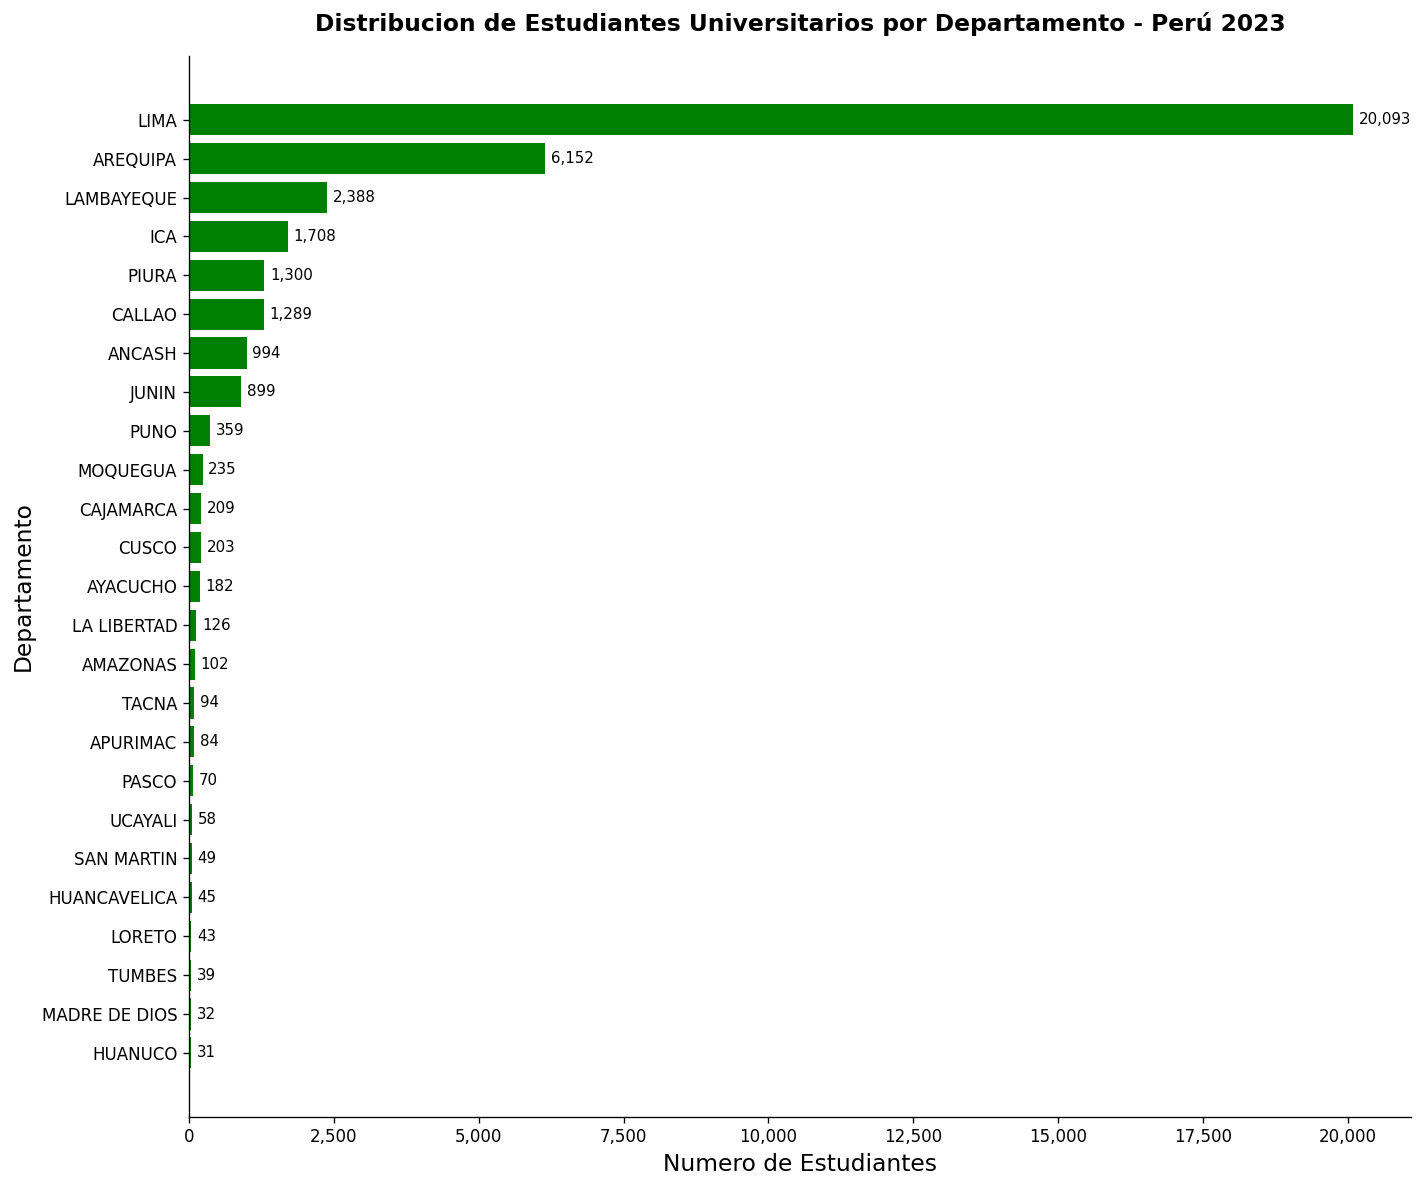

Grafico guardado como: Grafico_01_Estudiantes_por_Departamento.png


In [6]:
#Analisis 1: Distribucion de estudiantes por departamento
def estudiantes_por_departamento(df):
    conteo = (df.groupby('DEPARTMENT').size().reset_index(name='Estudiantes')
            .sort_values('Estudiantes', ascending=True))
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    bars = ax.barh(conteo['DEPARTMENT'], conteo['Estudiantes'], color='green')
    
    #Etiquetas en cada barra
    for bar in bars:
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,}", va='center', fontsize=9)
    
    ax.set_title('Distribucion de Estudiantes Universitarios por Departamento - Perú 2023',
                fontsize=14,fontweight='bold', pad=15)
    
    ax.set_xlabel('Numero de Estudiantes', fontsize=14)
    ax.set_ylabel('Departamento', fontsize=14)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    
    plt.tight_layout()
    plt.savefig('Grafico_01_Estudiantes_por_Departamento.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Grafico guardado como: Grafico_01_Estudiantes_por_Departamento.png")
estudiantes_por_departamento(df)

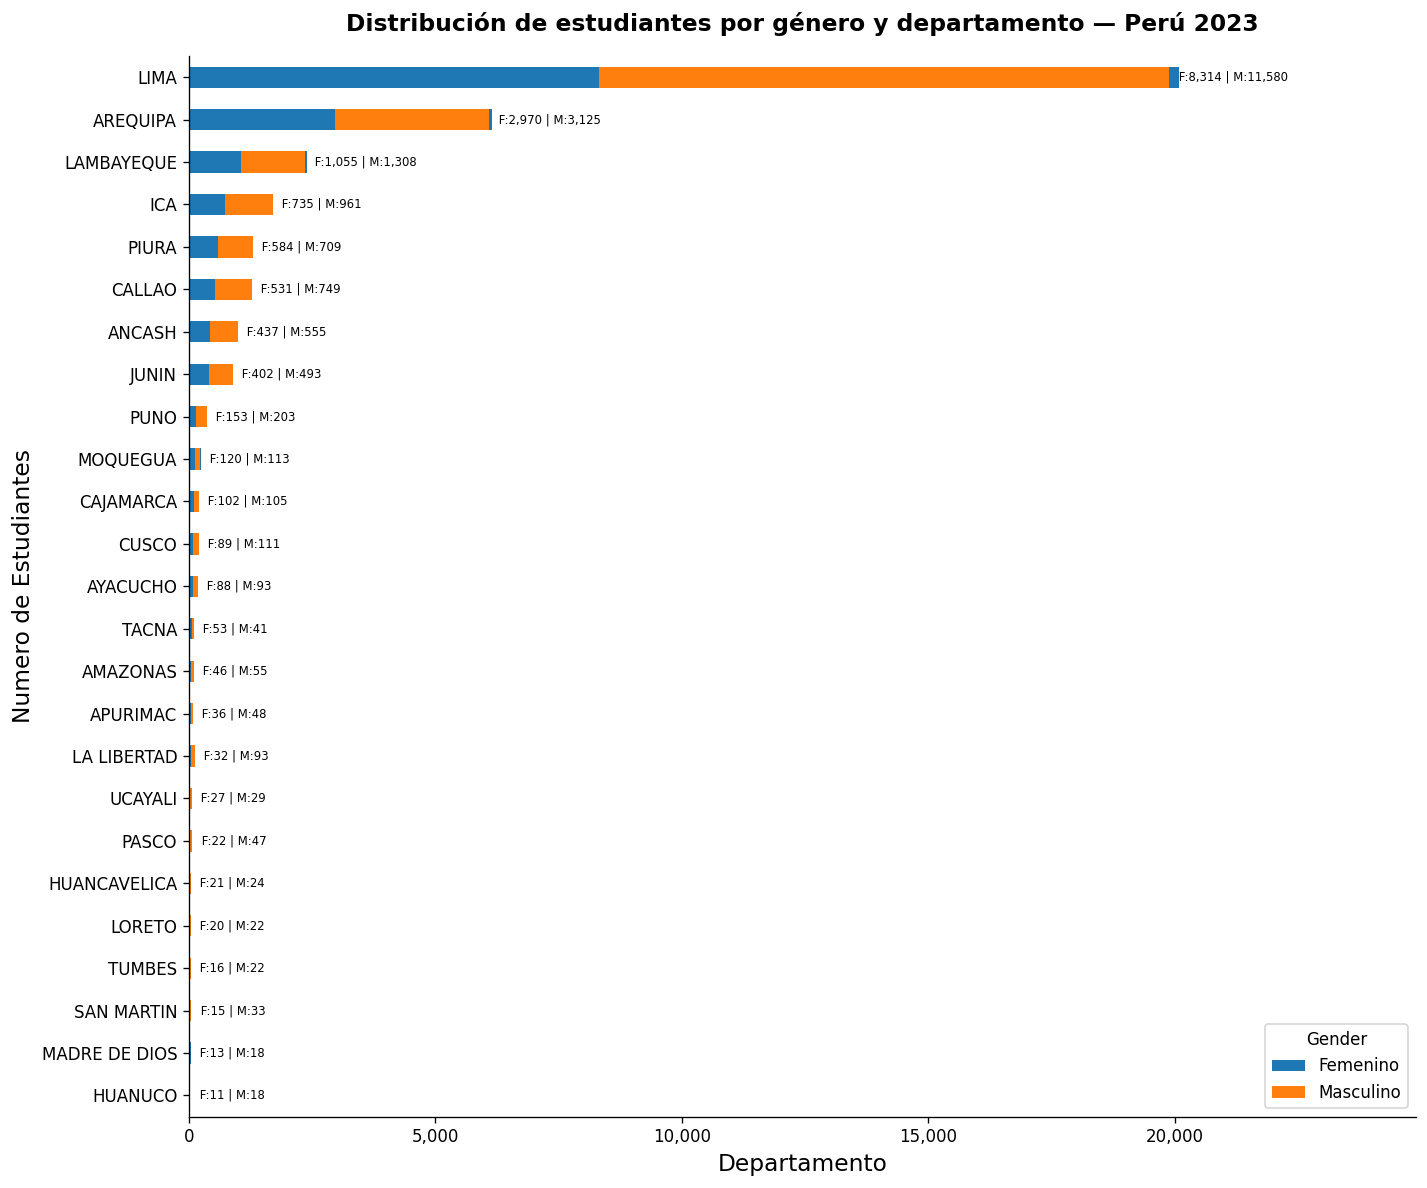

Grafico guardado como: Grafico_02_Genero_por_Departamento.png

-----TOP 5 DEPATAMENTOS CON MAS MUJERES-----


GENDER,F,M,NO ESPECIFICADO
DEPARTMENT,,,
LIMA,8314.0,11580.0,199.0
AREQUIPA,2970.0,3125.0,57.0
LAMBAYEQUE,1055.0,1308.0,25.0
ICA,735.0,961.0,12.0
PIURA,584.0,709.0,7.0


In [7]:
def genero_por_departamento(df):
    conteo = (df.groupby(['DEPARTMENT', 'GENDER']).size().reset_index(name='Estudiantes'))
    
    pivot = conteo.pivot(index='DEPARTMENT', columns='GENDER', values="Estudiantes").fillna(0)
    pivot = pivot.sort_values('F', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    pivot.plot(kind="barh", stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])
    
    ax.set_title('Distribución de estudiantes por género y departamento — Perú 2023',
                fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Numero de Estudiantes', fontsize=14)
    ax.set_xlabel('Departamento', fontsize=14)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(title='Gender', labels=['Femenino', 'Masculino'], loc='lower right')
    
    #Etiquetas en cada segmento
    for i, (idx, row) in enumerate(pivot.iterrows()):
        f_val = int(row.get('F', 0))
        m_val = int(row.get('M', 0))
        total = f_val + m_val

        if total > 0:
            conteo_valores = ax.get_xlim()[1] * 0.005
            ax.text(total + conteo_valores, i,
                    f" F:{f_val:,} | M:{m_val:,}",
                    va='center', ha='left', fontsize=7, color='black')

    ax.set_xlim(right=ax.get_xlim()[1] * 1.18)
    
    plt.tight_layout()
    plt.savefig('Grafico_02_Genero_por_Departamento.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico guardado como: Grafico_02_Genero_por_Departamento.png")
    
    print("\n-----TOP 5 DEPATAMENTOS CON MAS MUJERES-----")
    display(pivot.sort_values('F', ascending=False).head())
    
genero_por_departamento(df)

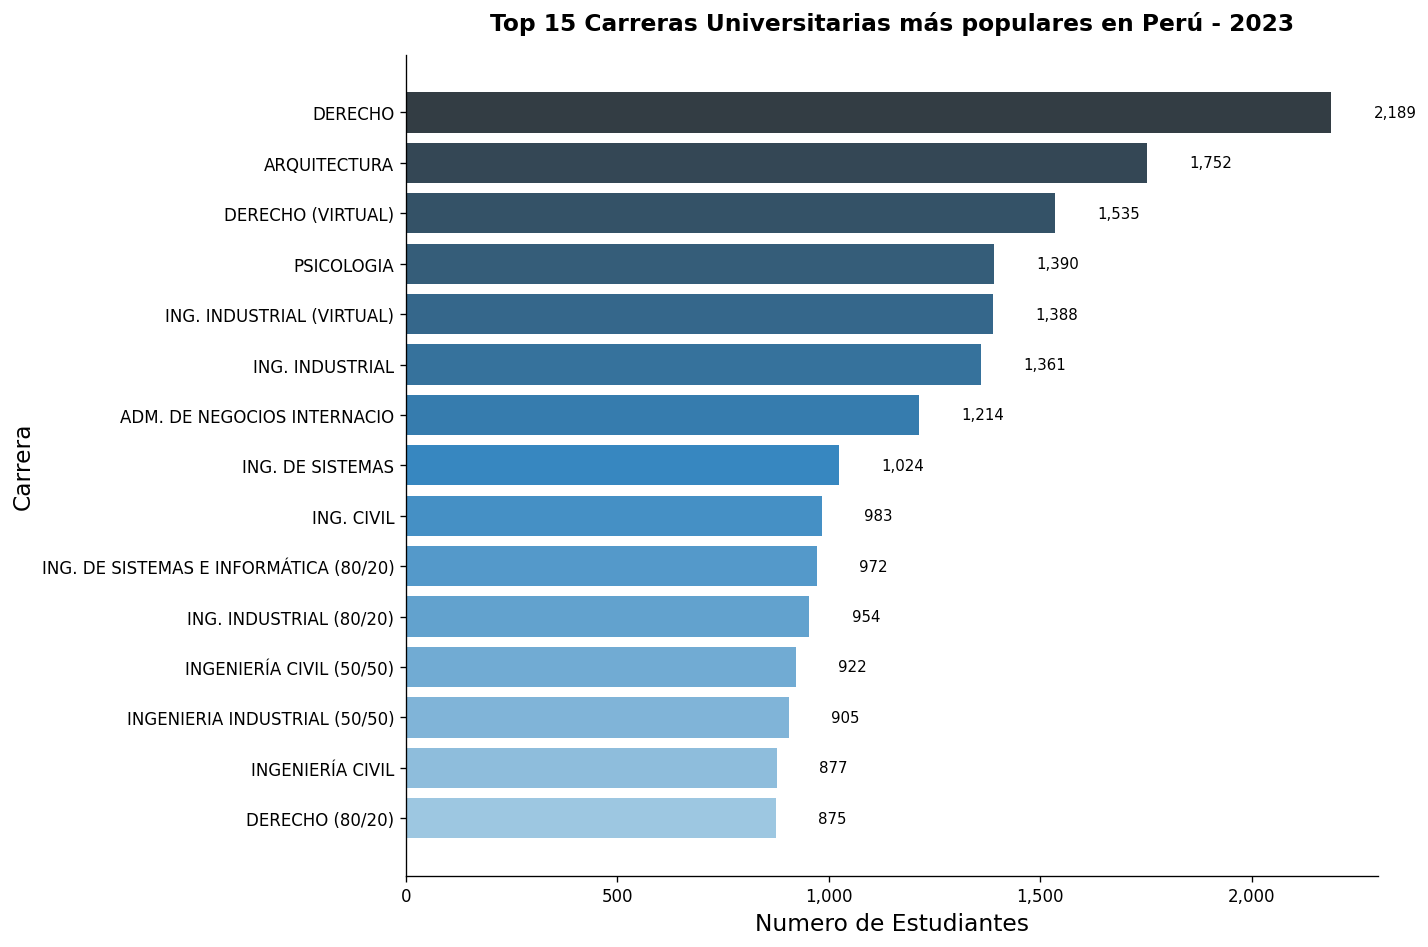

Grafico guardado como: Grafico_03_Top_Carreras.png

-----TOP 5 CARRERAS CON MAS ESTUDIANTES-----


,PROGRAM/MAJOR,Estudiantes,Porcentaje
24,DERECHO,2189,5.95
16,ARQUITECTURA,1752,4.76
27,DERECHO (VIRTUAL),1535,4.17
80,PSICOLOGIA,1390,3.78
55,ING. INDUSTRIAL (VIRTUAL),1388,3.77


In [8]:
#Analisis 3: Top 15 Carreras mas populares
def top_carreras(df, top=15):
    conteo = (df.groupby('PROGRAM/MAJOR').size().reset_index(name='Estudiantes')
            .sort_values('Estudiantes', ascending=False).head(top))
    
    conteo = conteo.sort_values('Estudiantes', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colores = sns.color_palette('Blues_d', n_colors=top)
    
    bars = ax.barh(conteo['PROGRAM/MAJOR'], conteo['Estudiantes'], color=colores, height=0.8)
    
    for bar in bars:
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,}", va= 'center', fontsize=9)
    
    ax.set_title('Top 15 Carreras Universitarias más populares en Perú - 2023',
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Numero de Estudiantes', fontsize=14)
    ax.set_ylabel('Carrera', fontsize=14)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    
    plt.tight_layout()
    plt.savefig('Grafico_03_Top_Carreras.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico guardado como: Grafico_03_Top_Carreras.png")
    
    print("\n-----TOP 5 CARRERAS CON MAS ESTUDIANTES-----")
    conteo_tabla = conteo.sort_values('Estudiantes', ascending=False)
    conteo_tabla['Porcentaje'] = (conteo_tabla['Estudiantes']/df.shape[0]*100).round(2)
    display(conteo_tabla.head())
top_carreras(df)

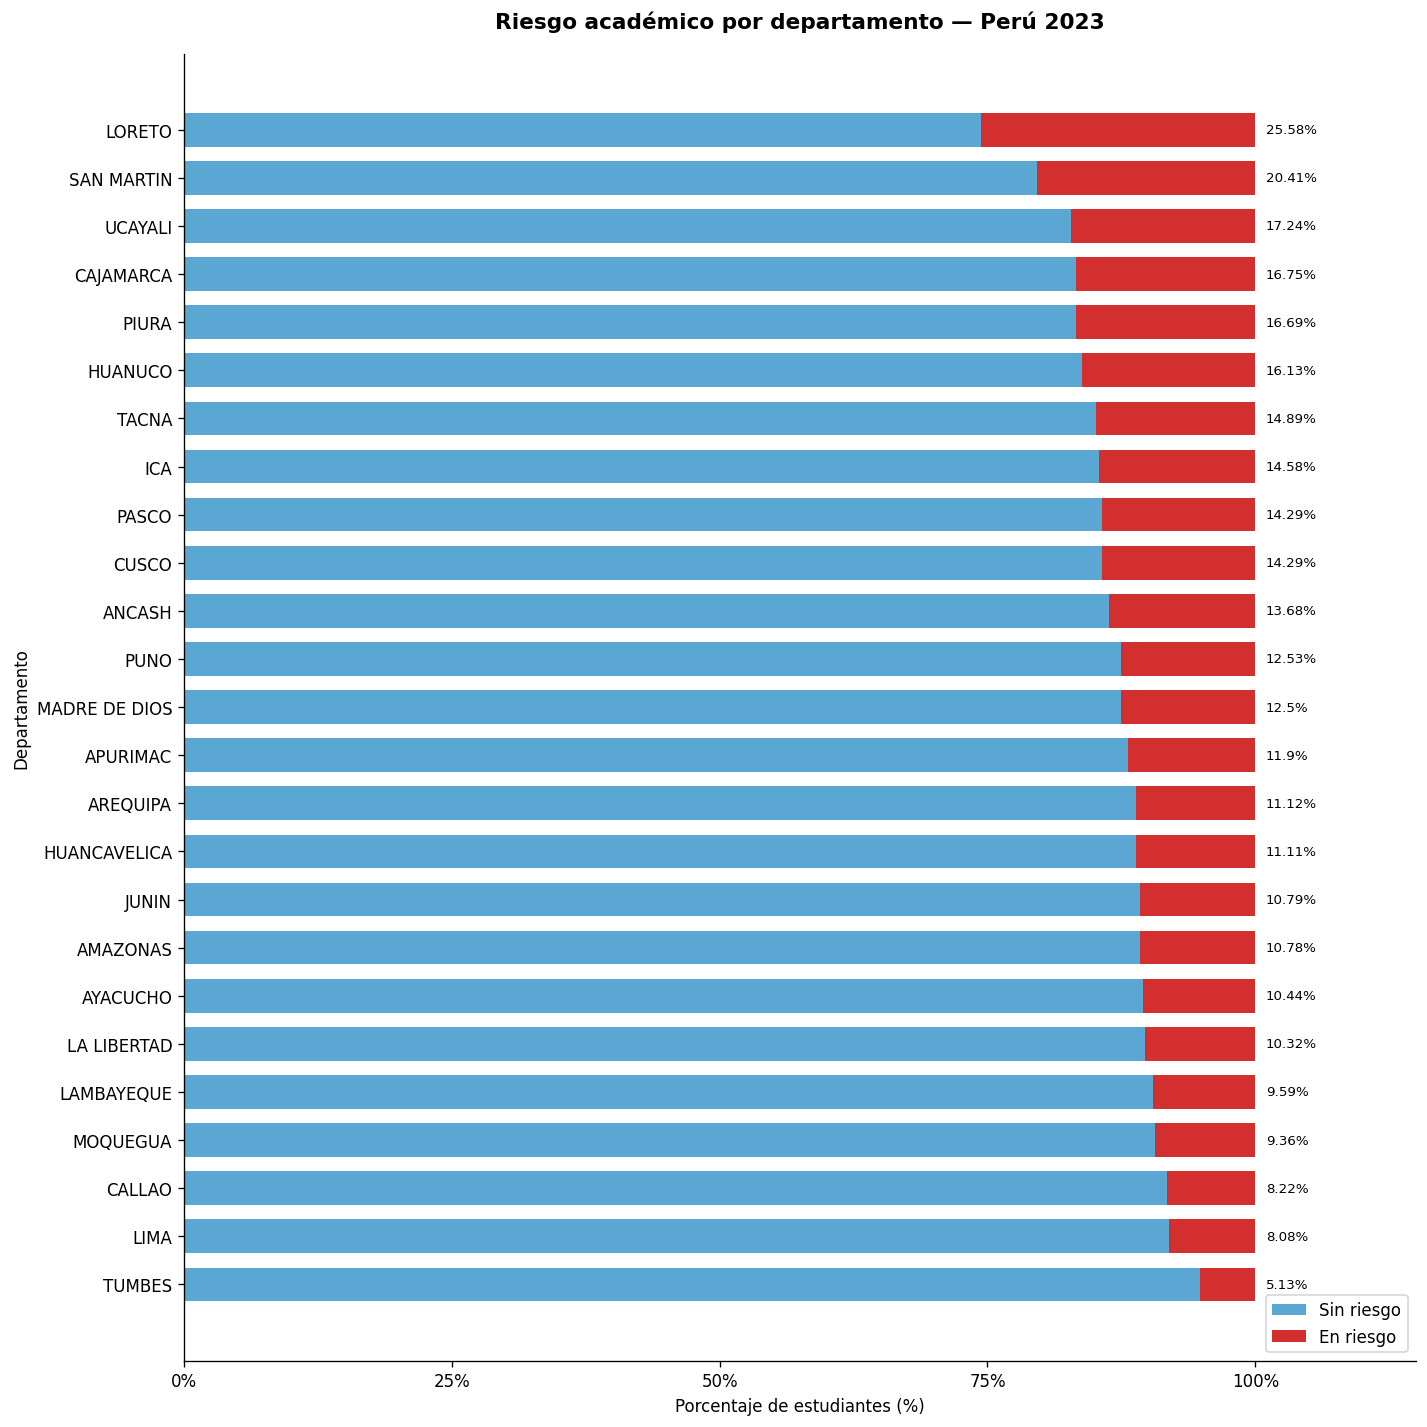

Gráfico guardado como grafico_04_riesgo_departamento.png

----TOP 5 DEPARTAMENTOS CON MAYOR RIESGO----


,DEPARTMENT,EN RIESGO,TOTAL,PCT_RIESGO
0,LORETO,11,43,25.58
1,SAN MARTIN,10,49,20.41
2,UCAYALI,10,58,17.24
3,CAJAMARCA,35,209,16.75
4,PIURA,217,1300,16.69



   Total departamentos analizados: 25


In [9]:
def riesgo_por_departamento(df):
    total_depto = df.groupby('DEPARTMENT').size().reset_index(name='TOTAL')
    riesgo_depto = (df[df['AT-RISK COURSE'] > 0]
                    .groupby('DEPARTMENT')
                    .size()
                    .reset_index(name='EN RIESGO'))

    conteo = total_depto.merge(riesgo_depto, on='DEPARTMENT', how='left')
    conteo['EN RIESGO'] = conteo['EN RIESGO'].fillna(0).astype(int)
    conteo['SIN RIESGO'] = conteo['TOTAL'] - conteo['EN RIESGO']
    conteo['PCT_RIESGO'] = (conteo['EN RIESGO'] / conteo['TOTAL'] * 100).round(2)
    conteo['PCT_SIN_RIESGO'] = 100 - conteo['PCT_RIESGO']
    conteo = conteo.sort_values('PCT_RIESGO', ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 12))

    ax.barh(conteo['DEPARTMENT'], conteo['PCT_SIN_RIESGO'],
            color='#5aa7d4', height=0.7, label='Sin riesgo')
    ax.barh(conteo['DEPARTMENT'], conteo['PCT_RIESGO'],
            left=conteo['PCT_SIN_RIESGO'],
            color='#d32f2f', height=0.7, label='En riesgo')

    for i, row in conteo.iterrows():
        ax.text(101, i,
                f"{row['PCT_RIESGO']}%",
                va='center', fontsize=8)

    ax.set_xlim(0, 115)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax.set_title('Riesgo académico por departamento — Perú 2023',
                    fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Porcentaje de estudiantes (%)')
    ax.set_ylabel('Departamento')
    ax.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('grafico_04_riesgo_departamento.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Gráfico guardado como grafico_04_riesgo_departamento.png")

    print("\n----TOP 5 DEPARTAMENTOS CON MAYOR RIESGO----")
    display(conteo.sort_values('PCT_RIESGO', ascending=False).head()[
        ['DEPARTMENT', 'EN RIESGO', 'TOTAL', 'PCT_RIESGO']
    ].reset_index(drop=True))

    print(f"\n   Total departamentos analizados: {len(conteo)}")

riesgo_por_departamento(df)

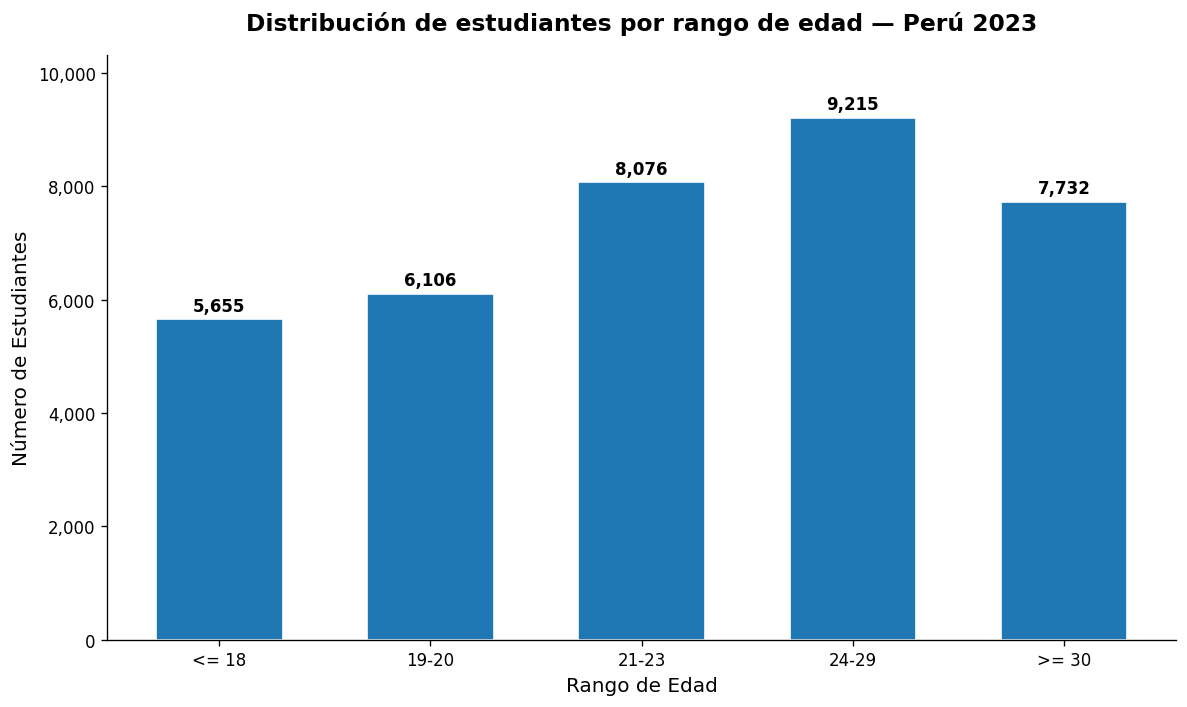

Grafico guardado como: Grafico_05_Rango_Edad.png

----- DISTRIBUCION POR RANGO DE EDAD -----


,Rango de Edad,Estudiantes,%
0,<= 18,5655,15.4
1,19-20,6106,16.6
2,21-23,8076,22.0
3,24-29,9215,25.1
4,>= 30,7732,21.0



   Rango más numeroso:  24-29 con 9,215 estudiantes (25.1%)
   Rango menos numeroso: <= 18 con 5,655 estudiantes (15.4%)
   Total estudiantes:    36,784


In [10]:
# Analisis 5: Rango de edad de estudiantes
def rango_edad_estudiantes(df):
    conteo = df['AGE RANGE OF ENROLLED STUDENT'].value_counts().sort_index()

    etiquetas = {
        '1. <=18':  '<= 18',
        '2. 19-20': '19-20',
        '3. 21-23': '21-23',
        '4. 24-29': '24-29',
        '5. >=30':  '>= 30'
    }
    conteo.index = conteo.index.map(etiquetas)

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(conteo.index, conteo.values, color='#1f77b4', edgecolor='white', width=0.6)

    for bar in bars:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, altura + 80,
                f"{int(altura):,}",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title('Distribución de estudiantes por rango de edad — Perú 2023',
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Rango de Edad', fontsize=12)
    ax.set_ylabel('Número de Estudiantes', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, conteo.max() * 1.12)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('Grafico_05_Rango_Edad.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico guardado como: Grafico_05_Rango_Edad.png")

    print("\n----- DISTRIBUCION POR RANGO DE EDAD -----")
    resumen = conteo.reset_index()
    resumen.columns = ['Rango de Edad', 'Estudiantes']
    resumen['%'] = (resumen['Estudiantes'] / resumen['Estudiantes'].sum() * 100).round(1)
    display(resumen)

    idx_max = resumen['Estudiantes'].idxmax()
    idx_min = resumen['Estudiantes'].idxmin()
    print(f"\n   Rango más numeroso:  {resumen.loc[idx_max, 'Rango de Edad']} "
        f"con {resumen.loc[idx_max, 'Estudiantes']:,} estudiantes "
        f"({resumen.loc[idx_max, '%']}%)")
    print(f"   Rango menos numeroso: {resumen.loc[idx_min, 'Rango de Edad']} "
        f"con {resumen.loc[idx_min, 'Estudiantes']:,} estudiantes "
        f"({resumen.loc[idx_min, '%']}%)")
    print(f"   Total estudiantes:    {resumen['Estudiantes'].sum():,}")

rango_edad_estudiantes(df)

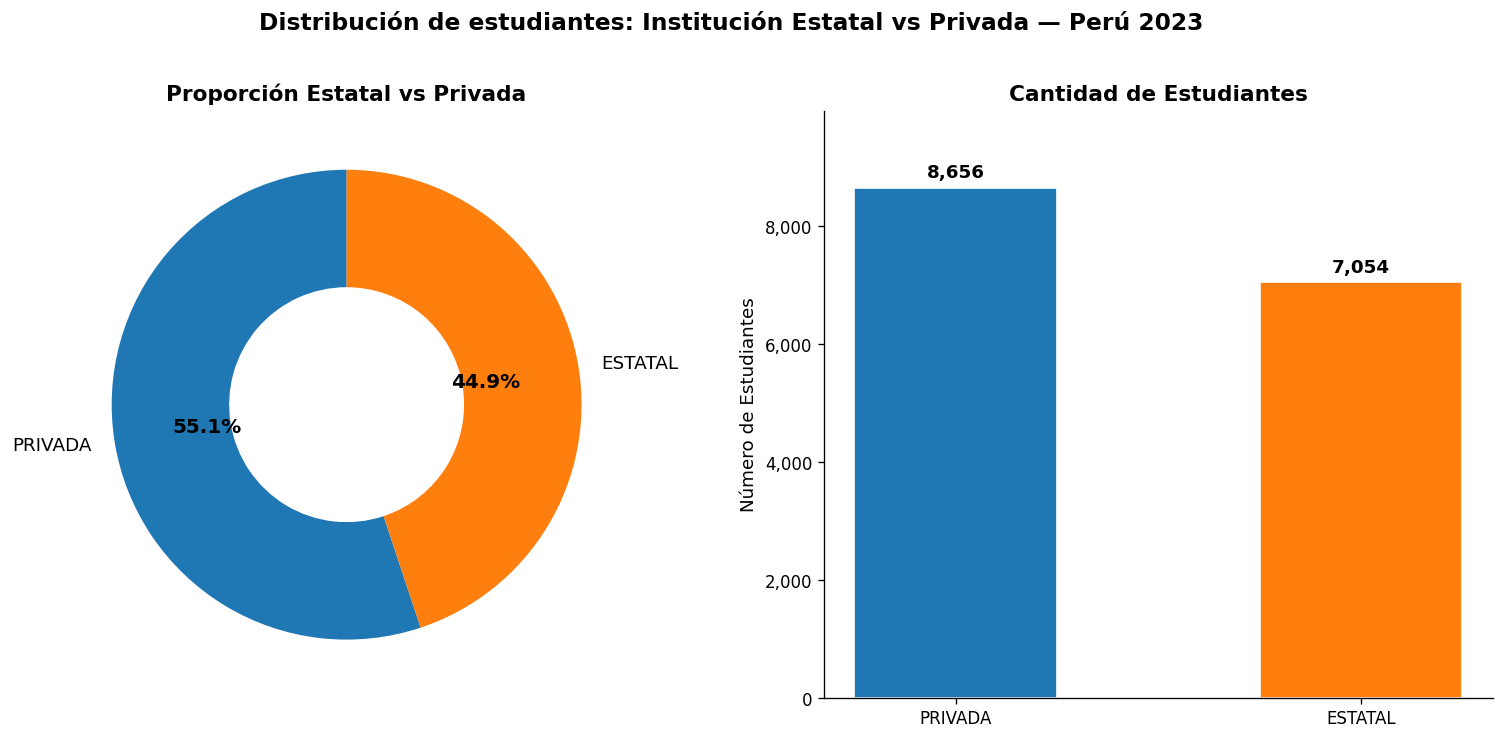

Grafico guardado como: Grafico_06_Estatal_vs_Privada.png

----- RESUMEN ESTATAL VS PRIVADA -----


,Tipo,Estudiantes,%
0,PRIVADA,8656,55.1
1,ESTATAL,7054,44.9



   Predomina la educación PRIVADA con el 55.1% de los estudiantes.
   Total estudiantes considerados: 15,710


In [11]:
# Analisis 6: Pública vs Privada
def publica_vs_privada(df):
    conteo = df['INSTITUTION STATUS'].value_counts()
    conteo = conteo[conteo.index.isin(['ESTATAL', 'PRIVADA'])]

    colores = ['#1f77b4', '#ff7f0e']

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    wedges, texts, autotexts = axes[0].pie(
        conteo.values,
        labels=conteo.index,
        autopct='%1.1f%%',
        colors=colores,
        startangle=90,
        wedgeprops=dict(width=0.5),
        textprops=dict(fontsize=11)
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
    axes[0].set_title('Proporción Estatal vs Privada', fontsize=13, fontweight='bold')

    bars = axes[1].bar(conteo.index, conteo.values, color=colores, width=0.5, edgecolor='white')
    for bar in bars:
        altura = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width() / 2, altura + 100,
                        f"{int(altura):,}",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[1].set_title('Cantidad de Estudiantes', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Número de Estudiantes', fontsize=11)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    axes[1].set_ylim(0, conteo.max() * 1.15)
    axes[1].spines[['top', 'right']].set_visible(False)

    fig.suptitle('Distribución de estudiantes: Institución Estatal vs Privada — Perú 2023',
                    fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig('Grafico_06_Estatal_vs_Privada.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico guardado como: Grafico_06_Estatal_vs_Privada.png")

    print("\n----- RESUMEN ESTATAL VS PRIVADA -----")
    resumen = conteo.reset_index()
    resumen.columns = ['Tipo', 'Estudiantes']
    resumen['%'] = (resumen['Estudiantes'] / resumen['Estudiantes'].sum() * 100).round(1)
    display(resumen)

    dominante = resumen.loc[resumen['Estudiantes'].idxmax(), 'Tipo']
    pct_dom   = resumen.loc[resumen['Estudiantes'].idxmax(), '%']
    print(f"\n   Predomina la educación {dominante} con el {pct_dom}% de los estudiantes.")
    print(f"   Total estudiantes considerados: {resumen['Estudiantes'].sum():,}")

publica_vs_privada(df)

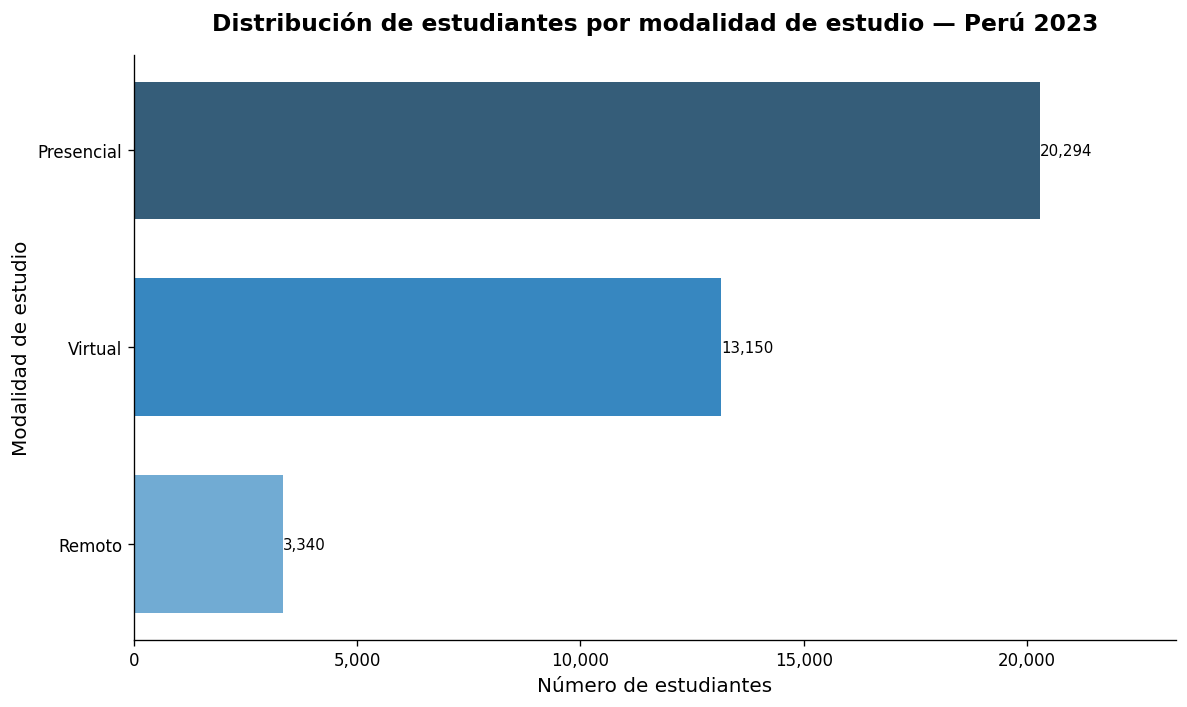

Grafico guardado como: Grafico_07_Modalidad_Estudio.png

----- MODALIDAD DE ESTUDIO -----


,STUDY MODE,Estudiantes,%
0,Presencial,20294,55.2
1,Virtual,13150,35.7
2,Remoto,3340,9.1



Modalidad predominante: Presencial con 20,294 estudiantes (55.2%).
La modalidad con menor participación es Remoto con 3,340 estudiantes (9.1%).
Se identificaron 3 modalidades de estudio registradas.


In [31]:
# Analisis 7: Distribución de estudiantes por modalidad de estudio
def modalidad_estudio(df):

    conteo = (df.groupby('STUDY MODE').size()
            .reset_index(name='Estudiantes')
            .sort_values('Estudiantes', ascending=False)
            .sort_values('Estudiantes', ascending=True))

    colores = sns.color_palette('Blues_d', n_colors=len(conteo))

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.barh(
        conteo['STUDY MODE'],
        conteo['Estudiantes'],
        color=colores,
        height=0.7
    )

    for bar in bars:
        ax.text(
            bar.get_width()+3,
            bar.get_y()+bar.get_height()/2,
            f"{int(bar.get_width()):,}",
            va='center',
            fontsize=9
        )

    ax.set_title(
        'Distribución de estudiantes por modalidad de estudio — Perú 2023',
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    ax.set_xlabel('Número de estudiantes', fontsize=12)
    ax.set_ylabel('Modalidad de estudio', fontsize=12)

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    ax.set_xlim(right=conteo['Estudiantes'].max()*1.15)

    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        'Grafico_07_Modalidad_Estudio.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print("Grafico guardado como: Grafico_07_Modalidad_Estudio.png")

    print("\n----- MODALIDAD DE ESTUDIO -----")

    tabla = (
        conteo.sort_values('Estudiantes', ascending=False)
        .reset_index(drop=True)
    )

    tabla['%'] = (
        tabla['Estudiantes'] / df.shape[0] * 100
    ).round(1)

    display(tabla)

    print(
        f"\nModalidad predominante: {tabla.loc[0,'STUDY MODE']} "
        f"con {tabla.loc[0,'Estudiantes']:,} estudiantes "
        f"({tabla.loc[0,'%']}%)."
    )

    print(
        f"La modalidad con menor participación es "
        f"{tabla.iloc[-1]['STUDY MODE']} "
        f"con {tabla.iloc[-1]['Estudiantes']:,} estudiantes "
        f"({tabla.iloc[-1]['%']}%)."
    )

    print(
        f"Se identificaron {len(tabla)} modalidades de estudio registradas."
    )

# Ejecutar
modalidad_estudio(df)

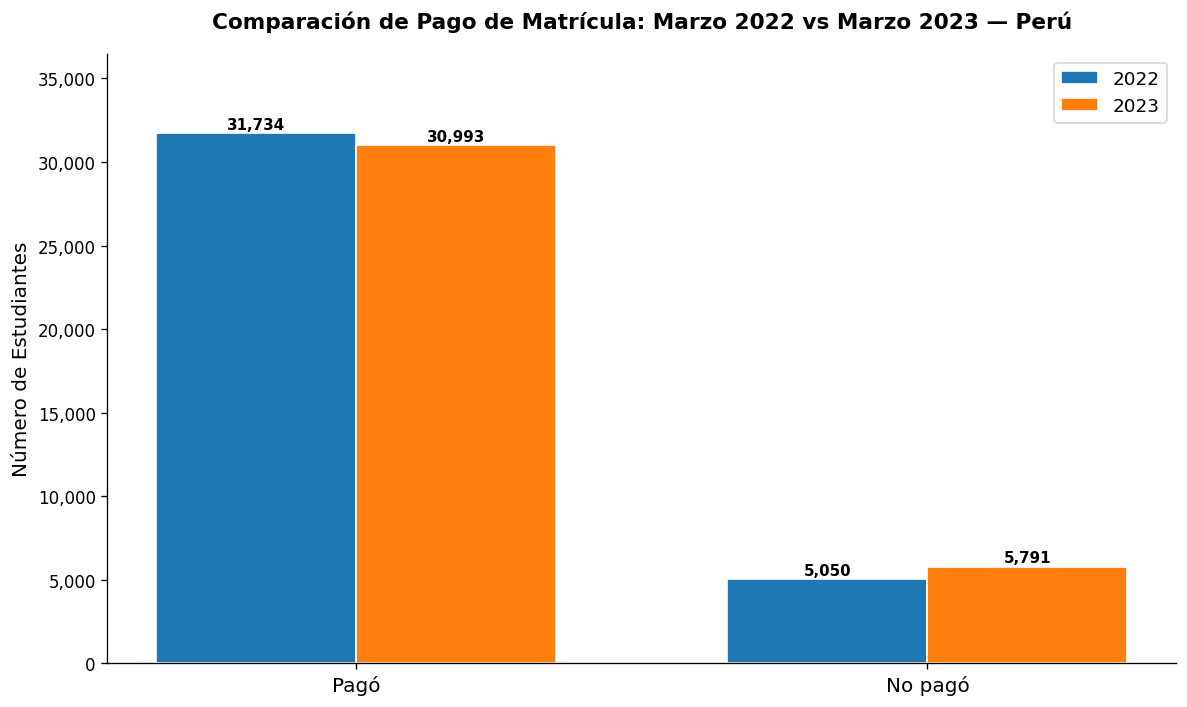

Grafico guardado como: Grafico_08_Pago_Matricula.png

----- RESUMEN PAGO DE MATRÍCULA -----


,Estado,2022,2023,Variación,% Variación
0,Pagó,31734,30993,-741,-2.3
1,No pagó,5050,5791,741,14.7



   El pago de matrícula disminuyó en 741 estudiantes (2.3%) de 2022 a 2023.
   Tasa de pago 2022: 86.3%
   Tasa de pago 2023: 84.3%


In [21]:
# Analisis 8: Pago de matrícula 2022 vs 2023
def pago_matricula_comparacion(df):
    col22 = 'TUITION PAYMENT MARCH 2022'
    col23 = 'TUITION PAYMENT MARCH 2023'

    pago22 = df[col22].value_counts().reindex([1, 0], fill_value=0)
    pago23 = df[col23].value_counts().reindex([1, 0], fill_value=0)

    etiquetas = ['Pagó', 'No pagó']
    x = np.arange(len(etiquetas))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    bars22 = ax.bar(x - ancho/2, [pago22[1], pago22[0]], ancho,
                    label='2022', color='#1f77b4', edgecolor='white')
    bars23 = ax.bar(x + ancho/2, [pago23[1], pago23[0]], ancho,
                    label='2023', color='#ff7f0e', edgecolor='white')

    for bar in list(bars22) + list(bars23):
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, altura + 80,
                f"{int(altura):,}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title('Comparación de Pago de Matrícula: Marzo 2022 vs Marzo 2023 — Perú',
                    fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Número de Estudiantes', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, max(pago22[1], pago23[1]) * 1.15)
    ax.legend(fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('Grafico_08_Pago_Matricula.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico guardado como: Grafico_08_Pago_Matricula.png")

    print("\n----- RESUMEN PAGO DE MATRÍCULA -----")
    resumen = pd.DataFrame({
        'Estado'    : etiquetas,
        '2022'      : [pago22[1], pago22[0]],
        '2023'      : [pago23[1], pago23[0]]
    })
    resumen['Variación'] = resumen['2023'] - resumen['2022']
    resumen['% Variación'] = ((resumen['Variación'] / resumen['2022']) * 100).round(1)
    display(resumen)

    var_pago = resumen.loc[resumen['Estado'] == 'Pagó', 'Variación'].values[0]
    pct_pago = resumen.loc[resumen['Estado'] == 'Pagó', '% Variación'].values[0]
    tendencia = "aumentó" if var_pago > 0 else "disminuyó"
    print(f"\n   El pago de matrícula {tendencia} en {abs(int(var_pago)):,} estudiantes "
            f"({abs(pct_pago)}%) de 2022 a 2023.")
    print(f"   Tasa de pago 2022: {pago22[1]/(pago22[1]+pago22[0])*100:.1f}%")
    print(f"   Tasa de pago 2023: {pago23[1]/(pago23[1]+pago23[0])*100:.1f}%")

pago_matricula_comparacion(df)

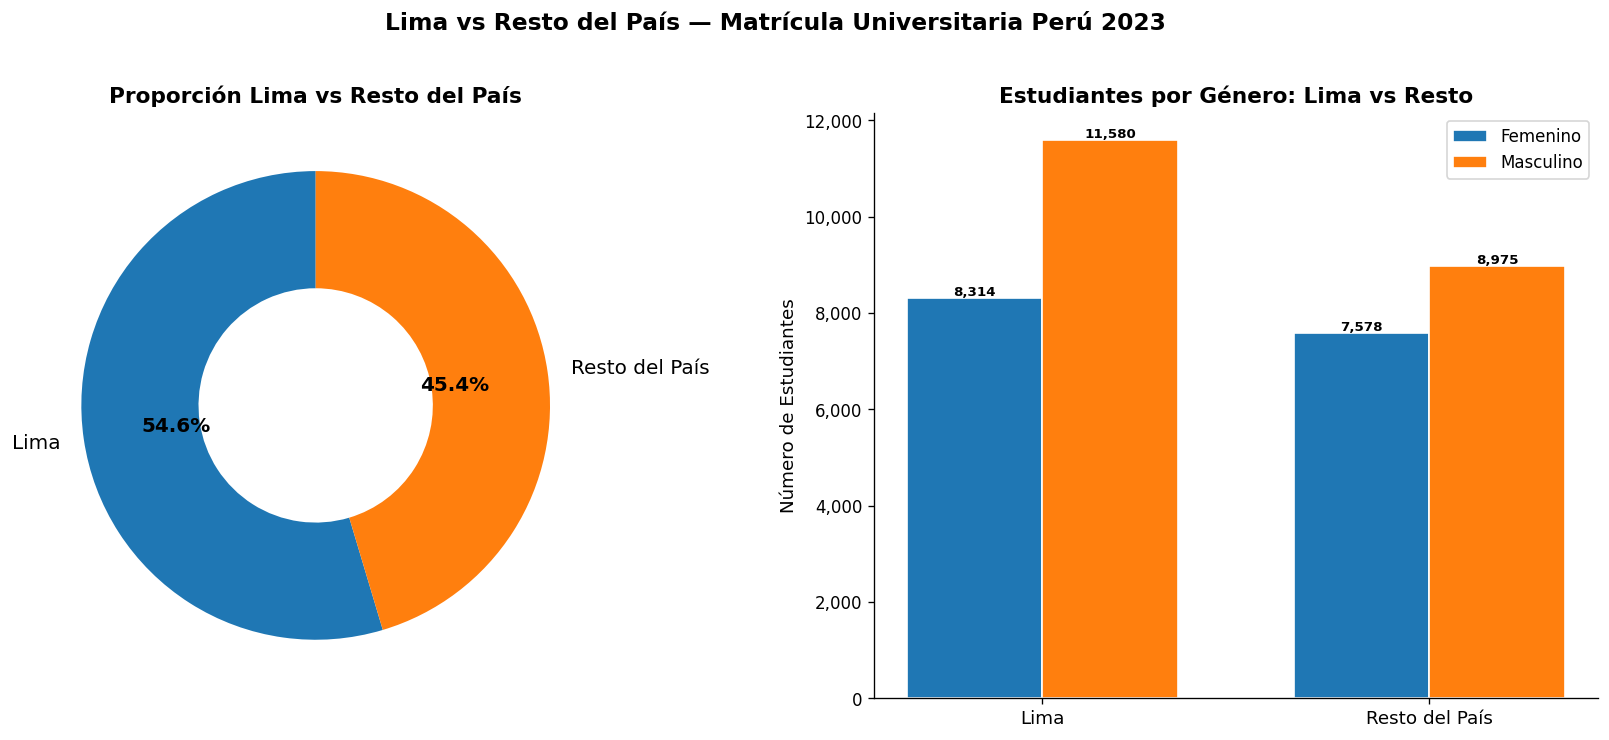

Grafico guardado como: Grafico_09_Lima_vs_Resto.png

----- RESUMEN LIMA VS RESTO DEL PAÍS -----


,Femenino,Masculino,Total,% del total
REGION,,,,
Lima,8314,11580,19894,54.6
Resto del País,7578,8975,16553,45.4



   Lima concentra 19,894 estudiantes (54.6% del total nacional).
   El resto del país suma 16,553 estudiantes distribuidos en 24 departamentos.
   Ratio Lima/Resto: 1.20x


In [15]:
# Analisis 9: Lima vs Resto del País
def lima_vs_resto(df):
    df_copia = df.copy()
    df_copia['REGION'] = df_copia['DEPARTMENT'].apply(
        lambda x: 'Lima' if x == 'LIMA' else 'Resto del País'
    )

    conteo = df_copia['REGION'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colores = ['#1f77b4', '#ff7f0e']

    wedges, texts, autotexts = axes[0].pie(
        conteo.values,
        labels=conteo.index,
        autopct='%1.1f%%',
        colors=colores,
        startangle=90,
        wedgeprops=dict(width=0.5),
        textprops=dict(fontsize=12)
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
    axes[0].set_title('Proporción Lima vs Resto del País', fontsize=13, fontweight='bold')

    genero_region = df_copia.groupby(['REGION', 'GENDER']).size().unstack(fill_value=0)
    genero_region = genero_region[['F', 'M']]

    x = np.arange(len(genero_region))
    ancho = 0.35

    axes[1].bar(x - ancho/2, genero_region['F'], ancho,
                label='Femenino', color='#1f77b4', edgecolor='white')
    axes[1].bar(x + ancho/2, genero_region['M'], ancho,
                label='Masculino', color='#ff7f0e', edgecolor='white')

    for i, (region, row) in enumerate(genero_region.iterrows()):
        axes[1].text(i - ancho/2, row['F'] + 50, f"{int(row['F']):,}",
                    ha='center', fontsize=8, fontweight='bold')
        axes[1].text(i + ancho/2, row['M'] + 50, f"{int(row['M']):,}",
                    ha='center', fontsize=8, fontweight='bold')

    axes[1].set_title('Estudiantes por Género: Lima vs Resto', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Número de Estudiantes', fontsize=11)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(genero_region.index, fontsize=11)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    axes[1].legend()
    axes[1].spines[['top', 'right']].set_visible(False)

    fig.suptitle('Lima vs Resto del País — Matrícula Universitaria Perú 2023',
                fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig('Grafico_09_Lima_vs_Resto.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafico guardado como: Grafico_09_Lima_vs_Resto.png")

    print("\n----- RESUMEN LIMA VS RESTO DEL PAÍS -----")
    resumen = df_copia.groupby(['REGION', 'GENDER']).size().unstack(fill_value=0)
    resumen = resumen[['F', 'M']]
    resumen.columns = ['Femenino', 'Masculino']
    resumen['Total'] = resumen['Femenino'] + resumen['Masculino']
    resumen['% del total'] = (resumen['Total'] / resumen['Total'].sum() * 100).round(1)
    display(resumen)

    lima_total  = resumen.loc['Lima', 'Total']
    resto_total = resumen.loc['Resto del País', 'Total']
    lima_pct    = resumen.loc['Lima', '% del total']
    print(f"\n   Lima concentra {lima_total:,} estudiantes ({lima_pct}% del total nacional).")
    print(f"   El resto del país suma {resto_total:,} estudiantes distribuidos en 24 departamentos.")
    print(f"   Ratio Lima/Resto: {lima_total/resto_total:.2f}x")

lima_vs_resto(df)

## 4. Conclusiones e Insights para el Sector

Con base en el análisis exploratorio de los datos de matrícula universitaria
del Perú 2023 (MINEDU ESCALE), se identificaron los siguientes hallazgos clave:


## 4. Conclusiones e Insights para el Sector

Con base en el análisis exploratorio de los datos de matrícula universitaria
del Perú 2023 (MINEDU ESCALE), se identificaron los siguientes hallazgos clave:

---

### INSIGHT 1 — CONCENTRACIÓN GEOGRÁFICA

Lima concentra el **54.6%** de todos los estudiantes universitarios del país
(20,093 de 36,784), seguida por Arequipa (6,152) y Lambayeque (2,388).
Esto revela una fuerte centralización de la educación superior en la capital,
mientras que departamentos como Huánuco, Madre de Dios o Tumbes registran
matrículas mínimas.

**→ Oportunidad:** Expandir la oferta de modalidad virtual en regiones
con baja cobertura presencial.

---

### INSIGHT 2 — BRECHA DE GÉNERO

A nivel nacional predominan los estudiantes masculinos (20,555) sobre los
femeninos (15,892), representando una brecha del 22.6%. Sin embargo, carreras
como Psicología y Derecho muestran una mayor participación femenina, mientras
que Ingeniería Industrial mantiene predominio masculino.

**→ Oportunidad:** Diseñar políticas de incentivo para reducir la brecha
de género en carreras STEM.

---

### INSIGHT 3 — CARRERAS MÁS DEMANDADAS

Derecho lidera la demanda con 2,189 estudiantes presenciales y sumando su
modalidad virtual (1,535) totaliza 3,724 matriculados, consolidándose como
la carrera más elegida del país. Le siguen Arquitectura (1,752) y
Psicología (1,390).

Destaca el crecimiento de la modalidad virtual: Ingeniería Industrial Virtual
(1,388) ya compite en volumen con carreras presenciales tradicionales.

**→ Oportunidad:** Fortalecer la infraestructura de educación virtual
dado su acelerado crecimiento.

---

### INSIGHT 4 — PERFIL ETARIO

El rango de edad dominante es **24-29 años** (9,215 estudiantes / 25.1%),
seguido por **21-23 años** (8,076 / 22.0%). Esto indica que una parte significativa
del estudiantado ingresa o continúa la educación superior más allá de la edad
tradicional (18-20 años).

Además, los mayores de 30 años representan el 21.0% (7,732), reflejando una
tendencia de educación continua y reinserción académica en adultos.

**→ Oportunidad:** Diseñar programas flexibles (nocturnos, virtuales,
semipresenciales) orientados al estudiante trabajador adulto.

---

### INSIGHT 5 — RIESGO ACADÉMICO

El **9.8%** de los estudiantes (3,597 de 36,784) tiene al menos un curso en riesgo
de desaprobar. Si bien la mayoría (90.2%) no presenta riesgo inmediato,
casi 1 de cada 10 estudiantes requiere intervención académica.

**→ Oportunidad:** Implementar sistemas de alerta temprana y tutorías
focalizadas en los departamentos con mayor porcentaje de riesgo.

---

### INSIGHT 6 — PAGO DE MATRÍCULA

El pago de matrícula disminuyó ligeramente de **31,734 estudiantes** en marzo de 2022
a **30,993** en marzo de 2023 (-741 estudiantes / -2.3%). Esto podría reflejar
dificultades económicas persistentes en algunos sectores o cambios en la
modalidad de pago.

**→ Oportunidad:** Revisar políticas de becas, fraccionamiento de pagos
y beneficios económicos para reducir la deserción por motivos financieros.

---

### INSIGHT 7 — MODALIDAD DE ESTUDIO

La **modalidad presencial** concentra la mayor parte de la matrícula universitaria
con **20,294 estudiantes (55.2%)**, consolidándose como la principal forma de acceso
a la educación superior en el país. La modalidad **virtual** ocupa el segundo lugar
con **13,150 estudiantes (35.7%)**, evidenciando una importante adopción de modelos
educativos digitales. Por su parte, la modalidad **remota** representa el **9.1%**
de la matrícula (3,340 estudiantes), siendo la alternativa con menor participación.

Estos resultados muestran que, aunque la enseñanza presencial continúa siendo
predominante, más de cuatro de cada diez estudiantes ya optan por modalidades
no presenciales, reflejando la transformación digital que atraviesa la educación
superior peruana.

**→ Oportunidad:** Fortalecer la infraestructura tecnológica, ampliar la oferta de
programas virtuales y semipresenciales, y garantizar la calidad académica en todas
las modalidades de estudio para responder a las nuevas necesidades de los estudiantes.

---

## RESUMEN EJECUTIVO

| Indicador | Valor |
|---|---|
| Total estudiantes analizados | 36,784 |
| Departamentos con cobertura | 25 |
| Período | Matrícula 2023 — MINEDU ESCALE |
| Lima vs resto del país | 54.6% vs 45.4% |
| Carrera más demandada | Derecho (presencial + virtual: 3,724) |
| Rango de edad predominante | 24-29 años (25.1%) |
| Estudiantes en riesgo académico | 9.8% (3,597) |
| Variación pago matrícula 2022→2023 | -2.3% (-741 estudiantes) |
| Modalidad de estudio predominante | Presencial (55.2%) |

**Hallazgos principales:**

- Lima concentra más de la mitad de la matrícula universitaria nacional (54.6%).
- Derecho es la carrera con mayor demanda considerando las modalidades presencial y virtual.
- Uno de cada cuatro estudiantes tiene entre 24 y 29 años.
- La modalidad presencial continúa liderando la matrícula con el 55.2%, mientras que la modalidad virtual ya representa el 35.7% del total.
- Cerca de 1 de cada 10 estudiantes presenta riesgo académico y requiere estrategias de acompañamiento.
- El pago de matrícula mostró una ligera disminución del 2.3% entre 2022 y 2023.
- La creciente participación de modalidades virtuales y remotas evidencia un proceso de transformación digital en la educación superior peruana.